# Notebook 5: Reserve Estimation

When a policyholder files a claim, Gulf Crest rarely knows its final cost on day one. Repairs take time,
adjusters revise estimates, and disputes get resolved months later. The amount a company sets aside today
for claims that have not yet fully settled is called a **reserve**, and getting it right matters directly:
too low, and the company understates what it actually owes; too high, and capital sits idle that could
otherwise be deployed.

This notebook builds reserve estimates two different ways:
1. **Chain Ladder**, using Gulf Crest's own claim payment history to project how a batch of claims
   develops over time
2. **Bornhuetter-Ferguson (BF)**, which blends that same historical pattern with an independent, outside
   estimate of expected losses, and is specifically suited to claims too new to have a reliable pattern of
   their own

Both are standard methods taught on the CAS syllabus. The point of this notebook is not just running the
formulas, but seeing exactly where Chain Ladder breaks down, and why BF exists to cover that gap.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

TODAY = pd.Timestamp("2026-08-17")  # about 30 days after Hurricane Marisol's landfall

DATA_DIR = "../04_Datasets/"
claims  = pd.read_csv(DATA_DIR + "02_claims.csv")
reserve_history = pd.read_csv(DATA_DIR + "07_reserve_history.csv")
financials = pd.read_csv(DATA_DIR + "08_company_financials.csv")

print("Data loaded.")

Data loaded.


## 1. What a Development Triangle Is

Reserving methods rely on a **development triangle**: claims grouped by the quarter they occurred in
(the **origin quarter**), tracked at successive intervals afterward (the **age**, in quarters since the
loss). Older origin quarters have had time to reach later ages; the newest origin quarters have only just
started, which is exactly why the table forms a triangle shape rather than a full rectangle.

`07_reserve_history.csv` records `cumulative_paid` at each review a claim went through. A claim that has
already closed will not generate any further reviews, so its last recorded value is carried forward for
every later age (the total paid on a finished claim does not disappear just because nobody logged another
review of it). The next cell builds that carried-forward view, one row per claim per age quarter.

In [2]:
claims["date_of_loss"] = pd.to_datetime(claims["date_of_loss"])
claims["origin_quarter"] = claims["date_of_loss"].dt.to_period("Q").astype(str)

# how many quarters have elapsed between the loss and today - this is how far a claim COULD have developed
claims["current_age_quarter"] = (
    (TODAY.to_period("Q") - claims["date_of_loss"].dt.to_period("Q")).apply(lambda x: x.n) + 1
)

merged = reserve_history.merge(
    claims[["claim_id", "origin_quarter", "is_catastrophe_flag", "current_age_quarter"]], on="claim_id"
)
merged["age_quarter"] = np.ceil(merged["development_month"] / 3).astype(int)

# the latest cumulative_paid value observed for each claim, within each age quarter it reached
last_per_age = merged.groupby(["claim_id", "age_quarter"])["cumulative_paid"].max().reset_index()

claim_meta = claims.set_index("claim_id")[["origin_quarter", "is_catastrophe_flag", "current_age_quarter"]]

carried_forward = []
for claim_id, group in last_per_age.groupby("claim_id"):
    meta = claim_meta.loc[claim_id]
    full_range = group.set_index("age_quarter").reindex(range(1, meta["current_age_quarter"] + 1))
    full_range["cumulative_paid"] = full_range["cumulative_paid"].ffill().fillna(0.0)
    full_range["claim_id"] = claim_id
    full_range["origin_quarter"] = meta["origin_quarter"]
    full_range["is_catastrophe_flag"] = meta["is_catastrophe_flag"]
    carried_forward.append(full_range.reset_index())

claim_development = pd.concat(carried_forward, ignore_index=True)
print(f"Claims with a formal reserve review on record: {claim_development['claim_id'].nunique()} of {len(claims)}")
claim_development.head()

Claims with a formal reserve review on record: 904 of 2883


,age_quarter,claim_id,cumulative_paid,origin_quarter,is_catastrophe_flag
0,1,CLM-000001,3003.95,2021Q1,N
1,2,CLM-000001,3003.95,2021Q1,N
2,3,CLM-000001,3003.95,2021Q1,N
3,4,CLM-000001,3003.95,2021Q1,N
4,5,CLM-000001,3003.95,2021Q1,N


## 2. Building the Triangle From Routine Claims

Only 904 of Gulf Crest's 2,883 claims have gone through a formal reserve review so far. This includes most
routine claims (which have had years to be reviewed) but only a small slice of the very recent Hurricane
Marisol claims. The triangle below is built from **routine claims only**, since they have enough history
to show a real development pattern. The Marisol claims are handled separately in Section 4, for reasons
that become clear once the routine pattern is in hand.

In [3]:
routine_development = claim_development[claim_development["is_catastrophe_flag"] == "N"]

triangle = routine_development.pivot_table(
    index="origin_quarter", columns="age_quarter", values="cumulative_paid", aggfunc="sum"
).sort_index()

# Development levels off well before two years (8 quarters); later columns are shown only far enough
# to confirm that leveling off, rather than printing the full 23-column tail.
display_triangle = triangle.loc[:, :8]
display_triangle.round(0)

age_quarter,1,2,3,4,5,6,7,8
origin_quarter,,,,,,,,
2021Q1,3004.0,3004.0,3004.0,3004.0,3004.0,3004.0,3004.0,3004.0
2021Q2,10428.0,10428.0,10428.0,10428.0,10428.0,10428.0,10428.0,10428.0
2021Q3,38523.0,45924.0,49779.0,49803.0,50558.0,48846.0,50708.0,50037.0
2021Q4,35162.0,35162.0,35162.0,35162.0,35162.0,35162.0,35162.0,35162.0
2022Q1,41123.0,44888.0,47108.0,47691.0,47222.0,48089.0,48010.0,47899.0
2022Q2,45842.0,53315.0,59480.0,59826.0,60366.0,60841.0,60684.0,60767.0
2022Q3,34649.0,45026.0,53333.0,54225.0,54521.0,53762.0,54324.0,54410.0
2022Q4,73210.0,106077.0,126719.0,124151.0,125941.0,126871.0,127016.0,129324.0
2023Q1,46750.0,46848.0,46848.0,46848.0,46848.0,46848.0,46848.0,46848.0


Reading a couple of rows: older origin quarters (top of the table) show a stable, fully developed
total by the later columns, while the most recent quarters (bottom rows) only have one or two columns filled
in so far. That gap is what Chain Ladder exists to fill in.

## 3. Chain Ladder: Projecting Ultimate Losses From the Pattern

For each pair of consecutive ages, an **age-to-age factor** captures how much, on average, claims grow
between one age and the next. It is computed only from origin quarters that have data at *both* ages, and
weighted by dollar volume (bigger origin quarters count for more, the same logic behind a weighted average
grade).

In [4]:
max_age = triangle.columns.max()
age_to_age_factors = {}

for age in range(1, max_age):
    column_now, column_next = triangle[age], triangle[age + 1]
    has_both = column_now.notna() & column_next.notna()
    age_to_age_factors[age] = column_next[has_both].sum() / column_now[has_both].sum()

factor_table = pd.Series(age_to_age_factors, name="age_to_age_factor").round(4)
factor_table.index.name = "age_quarter_to_next"
factor_table.head(8)

age_quarter_to_next
1    1.1234
2    1.0727
3    1.0066
4    0.9995
5    1.0003
6    1.0019
7    1.0012
8    1.0000
Name: age_to_age_factor, dtype: float64

Factors above 1.0 mean claims are still growing between those ages; a factor near 1.0 means claims
have essentially stopped moving. The **cumulative development factor (CDF)** from any given age to the
final, fully-developed value is the product of every remaining age-to-age factor from that point forward.
Ages beyond the last one observed are assumed fully developed, a simplifying assumption reasonable here
since the factors are already close to 1.0 by then.

In [5]:
cdf_to_ultimate = {}
for age in range(max_age, 0, -1):
    cdf_to_ultimate[age] = 1.0 if age == max_age else cdf_to_ultimate[age + 1] * age_to_age_factors[age]

cdf_series = pd.Series(cdf_to_ultimate, name="cdf_to_ultimate").sort_index().round(4)
cdf_series.index.name = "age_quarter"
cdf_series.head(8)

age_quarter
1    1.2165
2    1.0828
3    1.0095
4    1.0029
5    1.0034
6    1.0031
7    1.0012
8    1.0000
Name: cdf_to_ultimate, dtype: float64

In [6]:
def latest_observed(row):
    observed = row.dropna()
    if len(observed) == 0:
        return None, None
    latest_age = observed.index.max()
    return latest_age, observed[latest_age]

chain_ladder_rows = []
for origin_quarter, row in triangle.iterrows():
    age, paid_to_date = latest_observed(row)
    if age is None:
        continue
    cdf = cdf_to_ultimate.get(age, 1.0)
    chain_ladder_rows.append((origin_quarter, age, paid_to_date, cdf, paid_to_date * cdf))

chain_ladder_results = pd.DataFrame(
    chain_ladder_rows,
    columns=["origin_quarter", "latest_age_quarter", "paid_to_date", "cdf_to_ultimate", "chain_ladder_ultimate"]
)
chain_ladder_results["reserve_needed"] = (
    chain_ladder_results["chain_ladder_ultimate"] - chain_ladder_results["paid_to_date"]
)
chain_ladder_results.tail(8).round(2)

,origin_quarter,latest_age_quarter,paid_to_date,cdf_to_ultimate,chain_ladder_ultimate,reserve_needed
15,2024Q4,8,130655.92,1.00,130655.92,0.00
16,2025Q1,7,178413.28,1.00,178633.03,219.75
17,2025Q2,6,143395.08,1.00,143840.78,445.70
18,2025Q3,5,127212.26,1.00,127643.31,431.05
19,2025Q4,4,128508.35,1.00,128881.79,373.44
20,2026Q1,3,144257.95,1.01,145625.69,1367.74
21,2026Q2,2,101991.11,1.08,110438.80,8447.69
22,2026Q3,1,4125.81,1.22,5019.02,893.21


For routine claims, this works well: recent origin quarters that are still developing get an ultimate
estimate scaled up from what has been paid so far, based on how similar claims from earlier quarters
eventually turned out. **This is exactly the situation Chain Ladder is built for**: a claims population with
years of consistent history behind it.

## 4. Where Chain Ladder Breaks Down: Hurricane Marisol

Hurricane Marisol caused 2,021 claims, but only 43 of them have gone through a formal reserve review so
far, about 30 days after landfall. Applying the routine-claims development pattern to this handful of early
reviews shows exactly why Chain Ladder cannot be trusted here.

In [7]:
cat_claim_ids = claims.loc[claims["is_catastrophe_flag"] == "Y", "claim_id"]
reviewed_cat_claims = claim_development[claim_development["claim_id"].isin(cat_claim_ids)]

paid_so_far = reviewed_cat_claims.groupby("claim_id")["cumulative_paid"].max().sum()
total_cat_claims = len(cat_claim_ids)
reviewed_cat_count = reviewed_cat_claims["claim_id"].nunique()

print(f"Marisol claims reviewed so far: {reviewed_cat_count} of {total_cat_claims}")
print(f"Total paid across those reviewed claims: ${paid_so_far:,.2f}")

naive_cdf = cdf_to_ultimate[1]  # the routine-claims CDF from age 1 to ultimate
naive_chain_ladder_ultimate = paid_so_far * naive_cdf

print(f"\nRoutine-claims CDF from age 1 to ultimate: {naive_cdf:.4f}")
print(f"Naive Chain Ladder ultimate for Marisol (misapplying the routine pattern): ${naive_chain_ladder_ultimate:,.2f}")

Marisol claims reviewed so far: 43 of 2021
Total paid across those reviewed claims: $38,371.64

Routine-claims CDF from age 1 to ultimate: 1.2165
Naive Chain Ladder ultimate for Marisol (misapplying the routine pattern): $46,678.84


That estimate is obviously wrong, and worth stating plainly why:

1. **Wrong population.** The routine-claims development pattern reflects small, straightforward claims
   that mostly close within a year. Hurricane damage claims involve contractor scheduling, structural
   inspections, and higher dollar amounts, all of which take far longer to resolve. Borrowing a fast-paying
   claims pattern for a slow-paying catastrophe understates how much is still left to pay.
2. **Wrong denominator.** Only 43 of 2,021 claims have been reviewed at all. The $38 thousand paid so far
   is a tiny, unrepresentative slice of the total exposure, not a sample Chain Ladder's math can safely
   scale up from.

This is not a flaw in Chain Ladder itself. It is a flaw in using Chain Ladder on a claims population that
does not yet have a development pattern of its own to learn from. That is precisely the gap
Bornhuetter-Ferguson is built to close.

## 5. Bornhuetter-Ferguson: Blending a Prior Estimate With Actual Experience

BF starts from an **a priori (before the fact) expected ultimate loss**, an estimate that comes from
outside the claims development data entirely, and blends it with whatever has actually emerged so far. The
less has emerged, the more weight the prior estimate carries; as more claims get reviewed and more gets
paid, the actual experience takes over.

$$\text{BF Ultimate} = \text{Paid to Date} + \text{Prior Expected Ultimate} \times (1 - \text{Percent Paid Expected So Far})$$

**The prior.** Gulf Crest's adjusters have already produced an individual cost estimate for every claim,
recorded as `reported_severity`, whether or not that claim has gone through a formal reserve review yet.
Summing those bottom-up, claim-by-claim estimates across all 2,021 Marisol claims gives an independent
expected ultimate that does not depend on the thin paid-to-date data at all.

**Percent paid expected so far.** This cannot come from the routine-claims triangle, for the same reason
Chain Ladder failed above: routine and catastrophe claims pay out on entirely different schedules. For a
catastrophe this recent, industry experience (and the CAS research reviewed for this module) puts early
payment in the low single digits of the eventual total, since inspections, contractor availability, and
claim backlogs slow disbursement in the first weeks. 5% is used here as a stated, judgment-based assumption
rather than one derived from Gulf Crest's own data, which is itself a realistic feature of reserving a
brand-new type of event: the pattern has to come from somewhere, and sometimes that somewhere is outside
experience rather than the company's own claims.

In [8]:
prior_expected_ultimate = claims.loc[claims["is_catastrophe_flag"] == "Y", "reported_severity"].sum()
assumed_percent_paid_so_far = 0.05

bf_ultimate = paid_so_far + prior_expected_ultimate * (1 - assumed_percent_paid_so_far)
bf_reserve_needed = bf_ultimate - paid_so_far

print(f"Prior expected ultimate (sum of individual claim estimates): ${prior_expected_ultimate:,.2f}")
print(f"Assumed percent paid so far: {assumed_percent_paid_so_far:.0%}")
print(f"Paid to date: ${paid_so_far:,.2f}")
print(f"Bornhuetter-Ferguson ultimate: ${bf_ultimate:,.2f}")
print(f"Reserve needed (BF ultimate minus paid to date): ${bf_reserve_needed:,.2f}")

Prior expected ultimate (sum of individual claim estimates): $167,999,241.68
Assumed percent paid so far: 5%
Paid to date: $38,371.64
Bornhuetter-Ferguson ultimate: $159,637,651.24
Reserve needed (BF ultimate minus paid to date): $159,599,279.60


## 6. Comparing the Two Methods

In [9]:
comparison = pd.DataFrame({
    "Method": ["Naive Chain Ladder (routine pattern misapplied)", "Bornhuetter-Ferguson"],
    "Ultimate Estimate": [naive_chain_ladder_ultimate, bf_ultimate],
    "Reserve Needed": [naive_chain_ladder_ultimate - paid_so_far, bf_reserve_needed],
})
comparison["Ultimate Estimate"] = comparison["Ultimate Estimate"].map(lambda x: f"${x:,.0f}")
comparison["Reserve Needed"] = comparison["Reserve Needed"].map(lambda x: f"${x:,.0f}")
comparison

,Method,Ultimate Estimate,Reserve Needed
0,Naive Chain Ladder (routine pattern misapplied),"$46,679","$8,307"
1,Bornhuetter-Ferguson,"$159,637,651","$159,599,280"


The naive Chain Ladder estimate stays anchored to the tiny amount paid so far and comes out near
$47 thousand, a small fraction of what Gulf Crest actually owes. Bornhuetter-Ferguson, anchored instead to
the adjusters' own bottom-up claim estimates, lands close to $160 million, which is the figure Gulf Crest's
actuarial team could realistically stand behind at this early stage.

One boundary worth naming directly: this figure is the **gross** ultimate cost of Marisol claims, before
any recovery Gulf Crest receives from its reinsurance arrangements. The $44.5 million in `incurred_losses`
booked for 2026Q3 in `08_company_financials.csv` reflects the company's **net**, retained position across
its entire book of business for the quarter, not this cohort of claims in isolation, which is why the two
figures are not meant to reconcile directly. Reinsurance recoveries are outside the scope of this module.

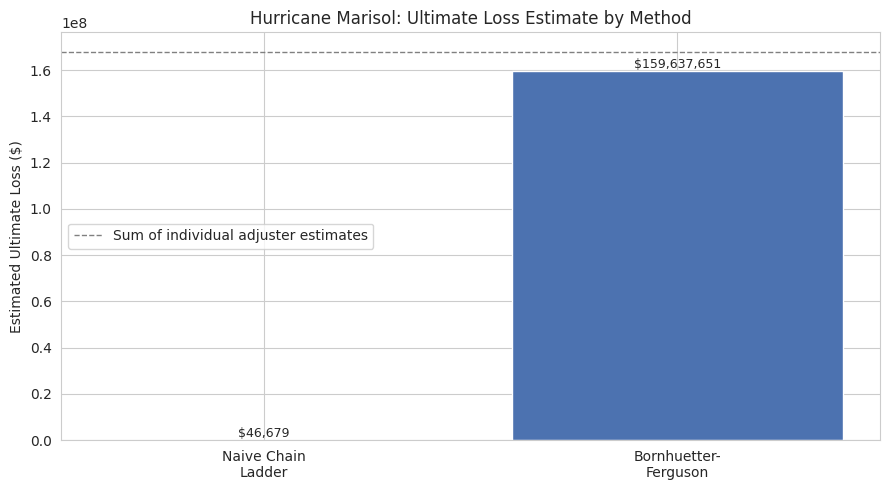

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
methods = ["Naive Chain\nLadder", "Bornhuetter-\nFerguson"]
values = [naive_chain_ladder_ultimate, bf_ultimate]
bars = ax.bar(methods, values, color=["#C44E52", "#4C72B0"])
ax.set_ylabel("Estimated Ultimate Loss ($)")
ax.set_title("Hurricane Marisol: Ultimate Loss Estimate by Method")
ax.axhline(prior_expected_ultimate, color="gray", linestyle="--", linewidth=1,
           label="Sum of individual adjuster estimates")
ax.legend()
for bar, value in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"${value:,.0f}",
            ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig("outputs_reserve_method_comparison.png", dpi=120)
plt.show()

## Summary

1. A development triangle organizes claims by when they occurred and how far they have developed, and its
   triangular shape reflects a simple fact: newer claims have not had time to develop as far as older ones.
2. Chain Ladder projects ultimate losses by scaling up paid-to-date using a pattern learned from the
   company's own claims history. It works well for routine claims with years of consistent development
   behind them.
3. Chain Ladder fails when applied to a claims population without its own development history. Misapplying
   the routine claims pattern to Hurricane Marisol understated the ultimate loss by roughly three orders of
   magnitude, because both the payment speed and the reviewed sample size were wrong for that population.
4. Bornhuetter-Ferguson solves this by blending an outside, a priori estimate with whatever has actually
   emerged so far, weighting the outside estimate more heavily while data is scarce. For Hurricane Marisol,
   this produced a reserve estimate anchored near the adjusters' own bottom-up figures rather than near the
   small amount paid out so far.
5. The percent-paid assumption behind a Bornhuetter-Ferguson estimate has to come from somewhere. For an
   established claims type, that can be the company's own history; for a genuinely new kind of event, it is
   often an external, judgment-based assumption, and being explicit about that assumption is part of doing
   the method honestly.

**Next:** Open `06_Optimization.ipynb` to look at how Gulf Crest should prioritize claims given limited
staff capacity.